# Dove vanno i soldi dei comuni italiani?
**Dataset**: `siope_uscite_comuni` (2021-2025) — SIOPE via GCS.

Analisi della spesa dei comuni italiani: trend nazionale, composizione per categoria, differenze regionali.
---

In [1]:
import duckdb
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150})
FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute("SET threads=4;")

GCS = "https://storage.googleapis.com/dataciviclab-clean/siope"
ANNI = list(range(2021, 2026))
parts = ' UNION ALL '.join(f"SELECT * FROM '{GCS}/siope_uscite_comuni/{a}/siope_uscite_comuni_{a}_clean.parquet'" for a in ANNI)
con.execute(f"CREATE OR REPLACE VIEW comuni AS SELECT * FROM ({parts}) WHERE tipo_ente = 'COMUNE'")

tot = con.execute("SELECT count(*) FROM comuni").fetchone()[0]
uniq = con.execute("SELECT count(DISTINCT codice_ente), count(DISTINCT regione) FROM comuni WHERE regione!=''").fetchone()
print(f"Righe: {tot:,} | Comuni: {uniq[0]:,} | Regioni: {uniq[1]}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Righe: 34,207,539 | Comuni: 7,910 | Regioni: 20


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,anno,mld
0,2021,95.56
1,2022,94.26
2,2023,99.17
3,2024,109.47
4,2025,114.20


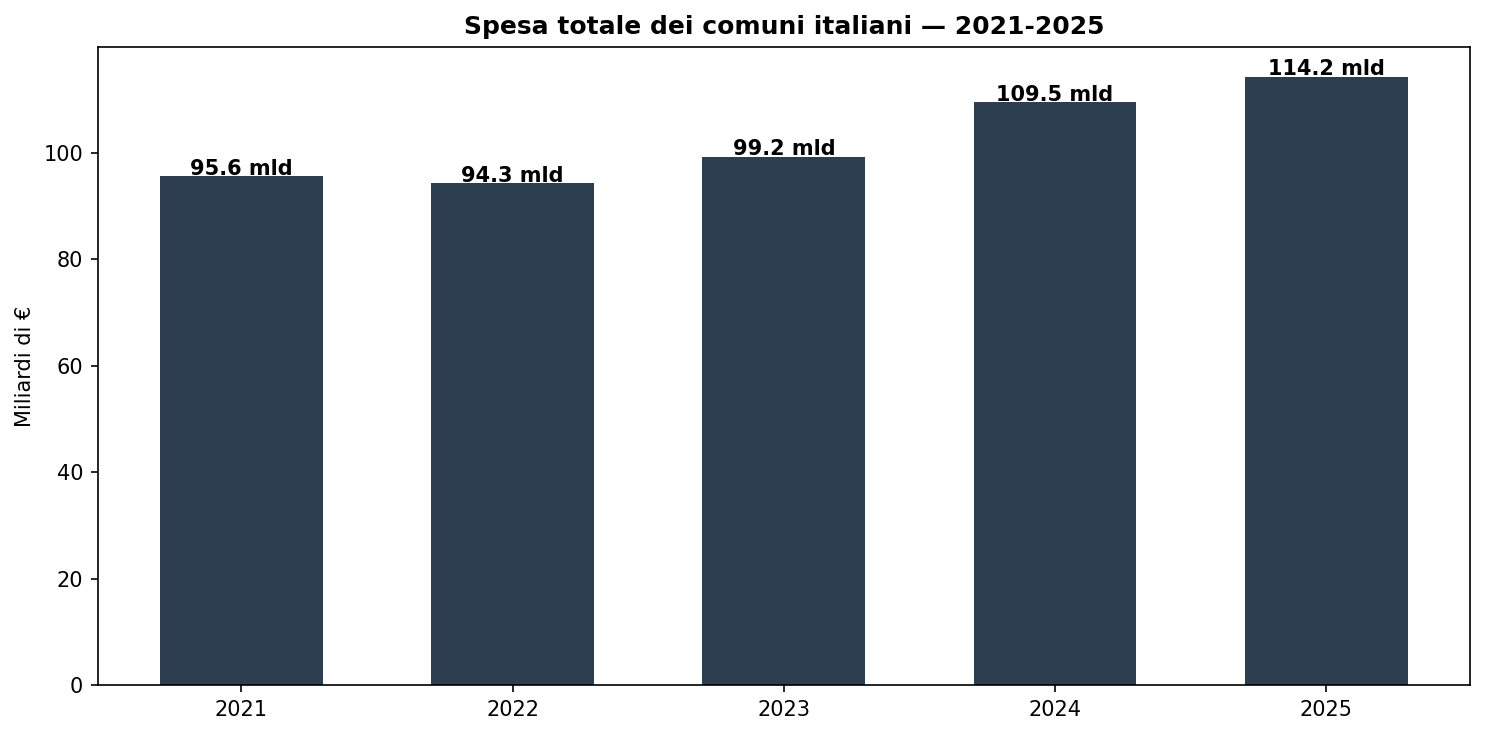

In [2]:
# 1. Trend nazionale 2021-2025
trend = con.execute('''
    SELECT anno, ROUND(SUM(importo_eur)/1e9,2) AS mld
    FROM comuni WHERE importo_eur>0 GROUP BY anno ORDER BY anno
''').fetchdf()
display(trend)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(trend['anno'].astype(str), trend['mld'], color='#2c3e50', width=0.6)
for i,v in enumerate(trend['mld']):
    ax.text(i, v+0.3, f'{v:.1f} mld', ha='center', fontweight='bold')
ax.set_title('Spesa totale dei comuni italiani — 2021-2025', fontweight='bold')
ax.set_ylabel('Miliardi di €')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'siope-comuni-spesa_trend_nazionale.png', bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

macro_categoria,Acquisto beni e servizi,Altre spese,Anticipazioni,Contributi investimenti,Personale,Rimborso prestiti,Trasferimenti c/capitale,Trasferimenti correnti
anno,,,,,,,,
2021,30.97,8.14,18.80,11.19,12.89,2.76,0.90,7.57
2022,33.14,6.23,16.77,11.64,13.23,2.66,0.92,7.39
2023,33.57,5.90,17.26,15.76,13.34,2.51,1.41,7.07
2024,36.01,6.71,19.01,19.12,13.86,2.66,1.55,8.07
2025,37.13,7.26,18.00,21.89,14.20,2.84,2.06,8.34


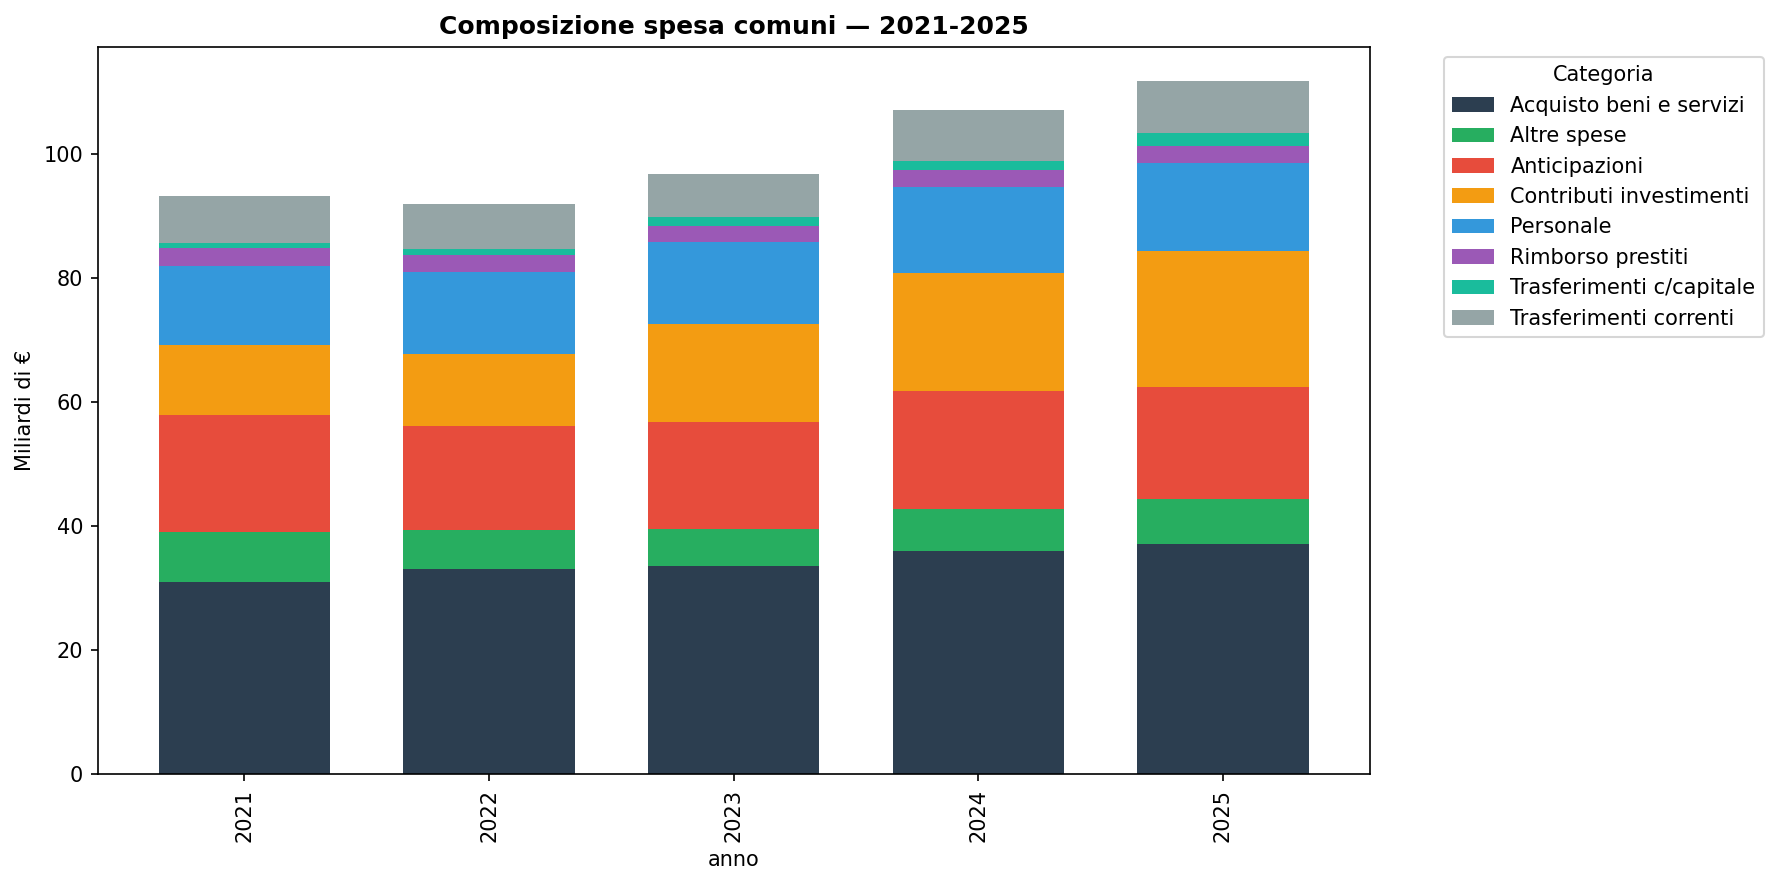

In [3]:
# 2. Composizione per macro-categoria
comp = con.execute('''
    SELECT anno, macro_categoria, ROUND(SUM(importo_eur)/1e9,2) AS mld
    FROM comuni
    WHERE macro_categoria NOT IN ('','NON CLASSIFICATO') AND importo_eur>0
    GROUP BY anno, macro_categoria ORDER BY anno, mld DESC
''').fetchdf()
top = comp[comp['anno']==max(ANNI)].head(8)['macro_categoria'].tolist()
pivot = comp[comp['macro_categoria'].isin(top)].pivot_table(index='anno', columns='macro_categoria', values='mld')
display(pivot)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2c3e50','#27ae60','#e74c3c','#f39c12','#3498db','#9b59b6','#1abc9c','#95a5a6']
pivot.plot(kind='bar', stacked=True, ax=ax, color=colors[:len(pivot.columns)], width=0.7)
ax.set_title('Composizione spesa comuni — 2021-2025', fontweight='bold')
ax.set_ylabel('Miliardi di €')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'siope-comuni-spesa_composizione_categorie.png', bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,regione,corrente,capitale,totale
0,LOMBARDIA,10.38,3.27,16.52
1,LAZIO,7.62,1.41,11.99
2,SICILIA,4.72,1.21,9.48
3,CAMPANIA,4.89,1.75,9.38
4,EMILIA-ROMAGNA,4.53,1.59,7.54
5,PIEMONTE,4.12,1.62,7.14
6,VENETO,4.20,1.68,7.13
7,TOSCANA,4.16,1.21,6.84
8,PUGLIA,3.46,1.16,5.74
9,CALABRIA,1.78,0.82,4.26


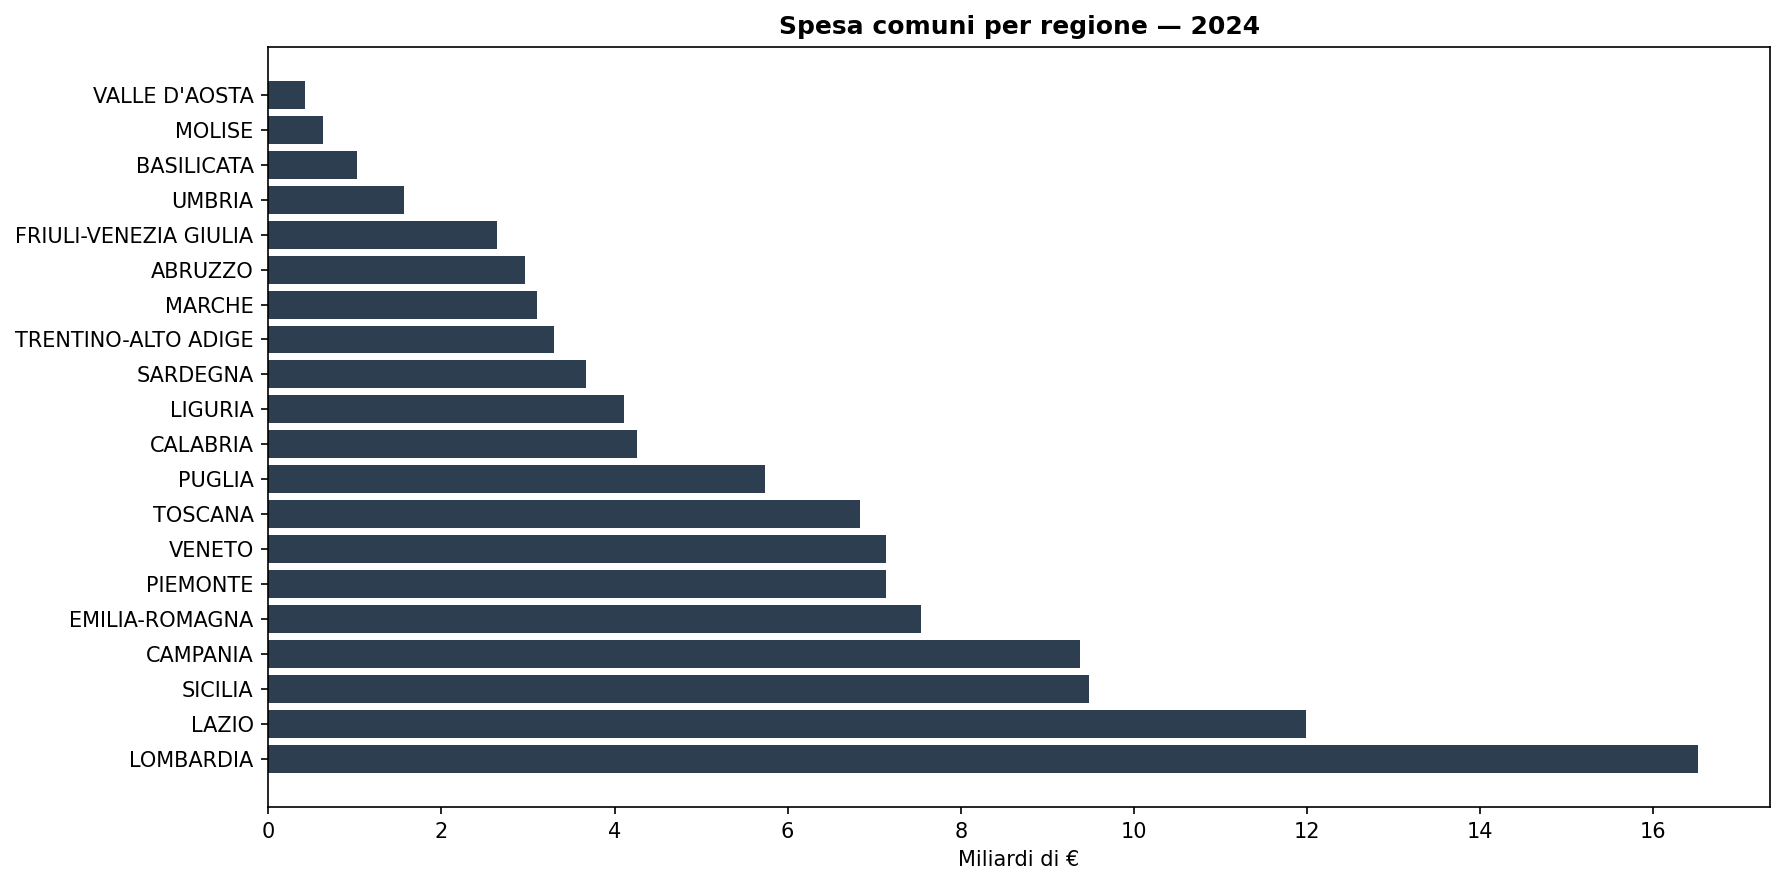

In [4]:
# 3. Spesa per regione (2024, anno completo)
reg = con.execute('''
    SELECT regione,
           ROUND(SUM(CASE WHEN macro_area='Spese correnti' THEN importo_eur ELSE 0 END)/1e9,2) AS corrente,
           ROUND(SUM(CASE WHEN macro_area='Spese in conto capitale' THEN importo_eur ELSE 0 END)/1e9,2) AS capitale,
           ROUND(SUM(importo_eur)/1e9,2) AS totale
    FROM comuni WHERE anno=2024 AND regione!='' AND importo_eur>0
    GROUP BY regione ORDER BY totale DESC
''').fetchdf()
display(reg.head(10))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(reg['regione'], reg['totale'], color='#2c3e50')
ax.set_title('Spesa comuni per regione — 2024', fontweight='bold')
ax.set_xlabel('Miliardi di €')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'siope-comuni-spesa_spesa_regioni.png', bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,descrizione_codice,macro_categoria,mld
0,Contratti di servizio per la raccolta rifiuti,Acquisto beni e servizi,8.84
1,Voci stipendiali corrisposte al personale a te...,Personale,8.35
2,Versamento delle ritenute per scissione contab...,Anticipazioni,4.74
3,Infrastrutture stradali,Contributi investimenti,4.19
4,Utilizzo incassi vincolati ai sensi dell?art....,Anticipazioni,4.07
5,Destinazione incassi liberi al reintegro inc...,Anticipazioni,3.96
6,Altri servizi diversi n.a.c.,Acquisto beni e servizi,3.39
7,Fabbricati ad uso scolastico,Contributi investimenti,2.99
8,Beni immobili n.a.c.,Contributi investimenti,2.86
9,Contributi obbligatori per il personale,Personale,2.85


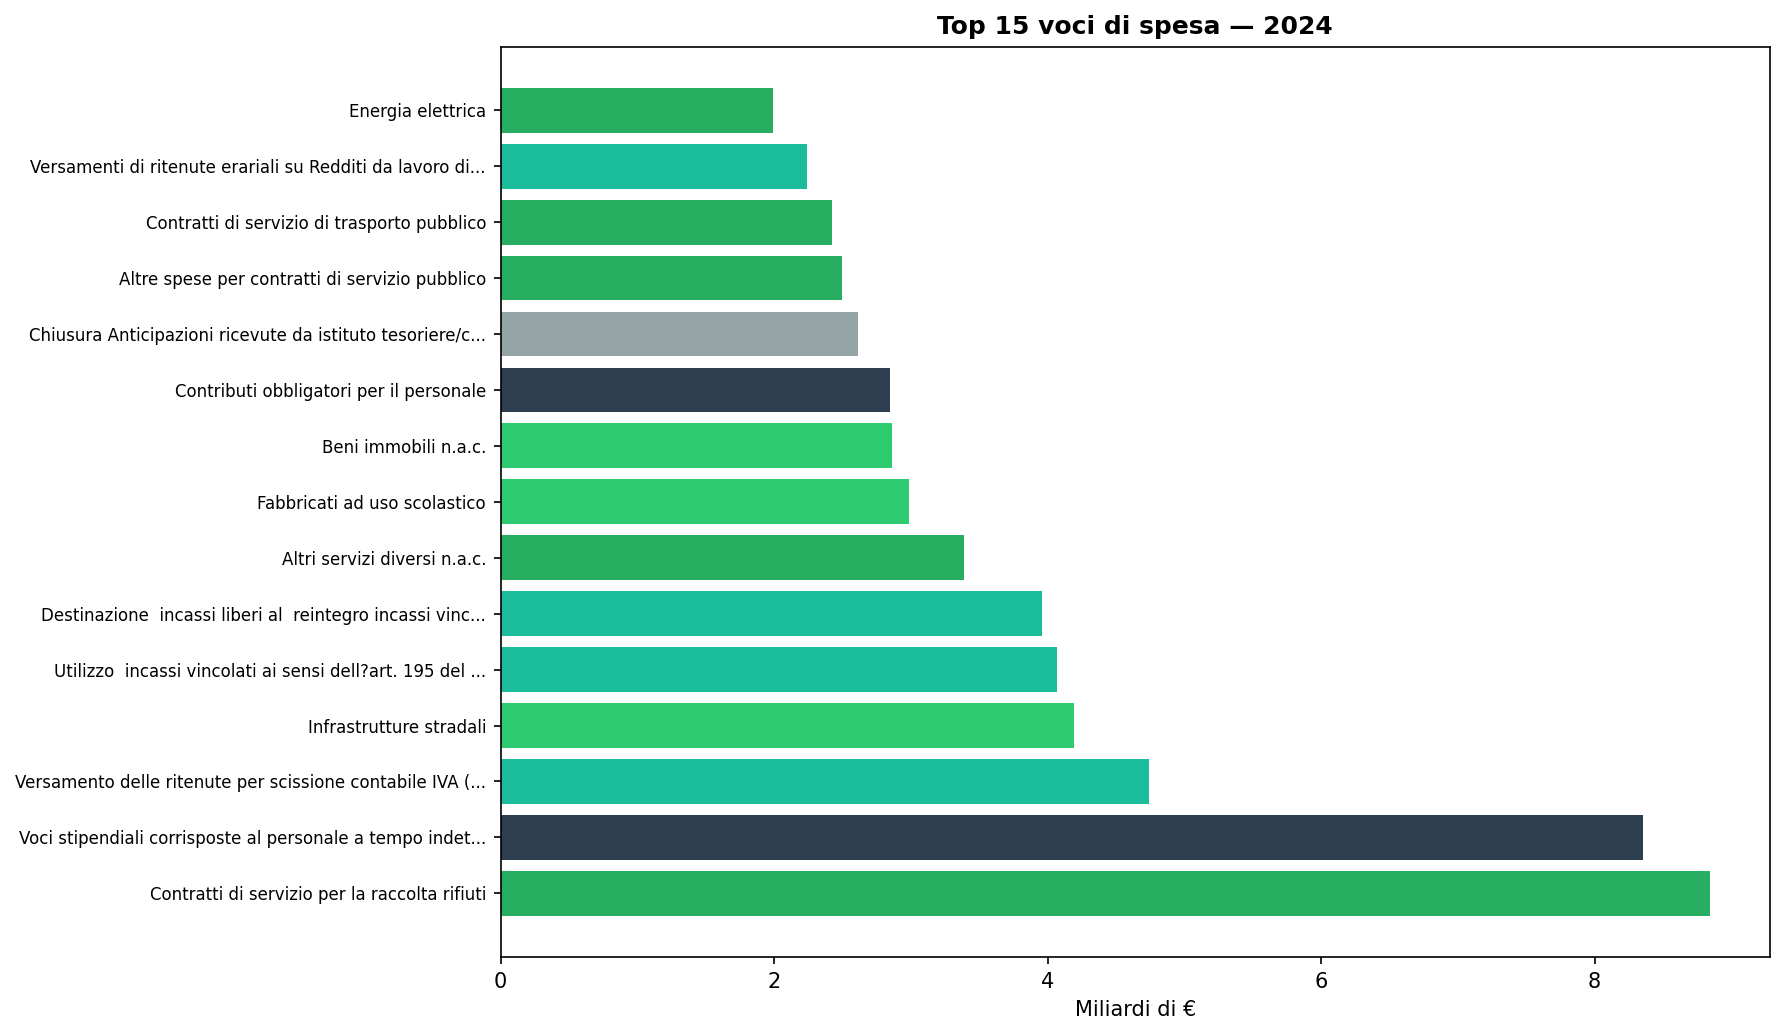

In [5]:
# 4. Top voci di spesa 2024
voci = con.execute('''
    SELECT descrizione_codice, macro_categoria, ROUND(SUM(importo_eur)/1e9,2) AS mld
    FROM comuni
    WHERE anno=2024 AND descrizione_codice!='' AND importo_eur>0
    GROUP BY descrizione_codice, macro_categoria
    ORDER BY mld DESC LIMIT 15
''').fetchdf()
display(voci)

pal = {'Personale':'#2c3e50','Acquisto beni e servizi':'#27ae60','Investimenti fissi':'#e74c3c',
       'Trasferimenti correnti':'#3498db','Altre spese':'#95a5a6','Imposte e tasse':'#f39c12',
       'Rimborso prestiti':'#9b59b6','Anticipazioni':'#1abc9c','Trasferimenti c/capitale':'#e67e22',
       'Contributi investimenti':'#2ecc71'}
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(len(voci)), voci['mld'], color=[pal.get(c,'#95a5a6') for c in voci['macro_categoria']])
ax.set_yticks(range(len(voci)))
ax.set_yticklabels([(t[:55]+'...') if len(t)>55 else t for t in voci['descrizione_codice']], fontsize=8)
ax.set_xlabel('Miliardi di €')
ax.set_title('Top 15 voci di spesa — 2024', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'siope-comuni-spesa_top_voci.png', bbox_inches='tight')
plt.show()

,regione,incidenza
0,TRENTINO-ALTO ADIGE,14.6
1,FRIULI-VENEZIA GIULIA,14.5
2,PIEMONTE,14.4
3,TOSCANA,14.0
4,VENETO,13.8
5,UMBRIA,13.6
6,EMILIA-ROMAGNA,13.5
7,LOMBARDIA,13.3
8,LAZIO,13.3
9,SICILIA,12.8


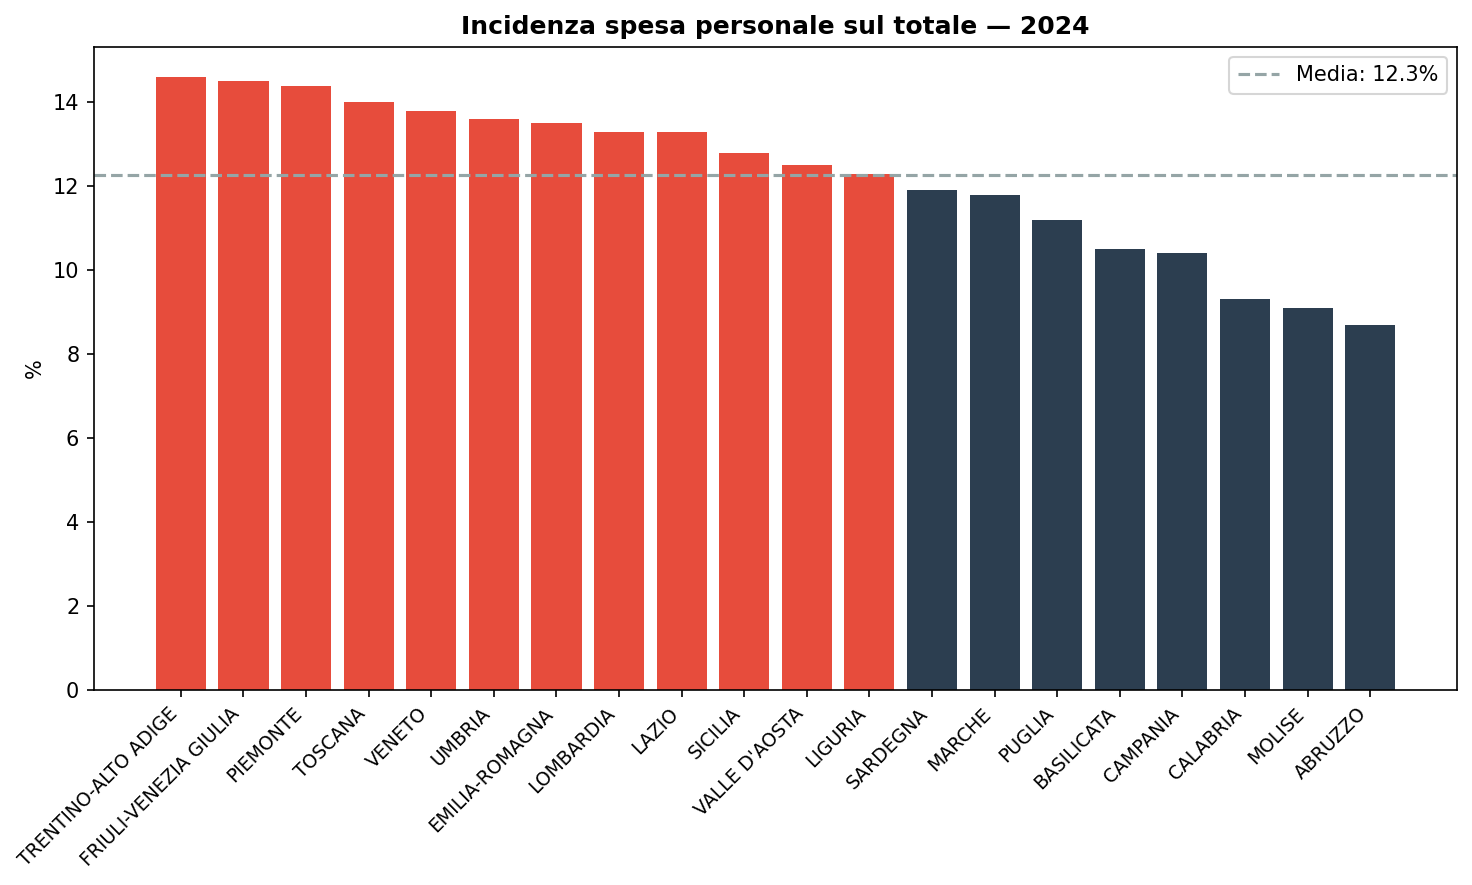

In [6]:
# 5. Incidenza personale per regione
pers = con.execute('''
    SELECT regione,
           ROUND(SUM(CASE WHEN macro_categoria='Personale' THEN importo_eur ELSE 0 END)/SUM(importo_eur)*100,1) AS incidenza
    FROM comuni WHERE anno=2024 AND regione!='' AND importo_eur>0
    GROUP BY regione HAVING SUM(importo_eur)>1e8 ORDER BY incidenza DESC
''').fetchdf()
display(pers)

media = pers['incidenza'].mean()
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(pers['regione'], pers['incidenza'],
       color=['#e74c3c' if v>media else '#2c3e50' for v in pers['incidenza']])
ax.axhline(y=media, color='#95a5a6', linestyle='--', linewidth=1.5, label=f'Media: {media:.1f}%')
ax.set_title('Incidenza spesa personale sul totale — 2024', fontweight='bold')
ax.set_ylabel('%')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'siope-comuni-spesa_incidenza_personale.png', bbox_inches='tight')
plt.show()

In [7]:
# 6. Cleanup
con.close()
print('Chiuso.')
print('Figure:', sorted(p.name for p in FIGURES_DIR.glob('*.png')))

Chiuso.
Figure: ['siope-comuni-spesa_composizione_categorie.png', 'siope-comuni-spesa_incidenza_personale.png', 'siope-comuni-spesa_spesa_regioni.png', 'siope-comuni-spesa_top_voci.png', 'siope-comuni-spesa_trend_nazionale.png']
